# 💧 AquaGuard — Data Generation Notebook
Run this notebook **once** (or whenever you want fresh data).
It generates sensor readings and saves them to `data/sensor_data.csv`.
The Streamlit app will detect the file and offer to load it instead of re-generating.

In [2]:
import sys, os
# Make sure we can import from project root
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
from modules.sensor  import generate_dataframe
from modules.data_io import save_csv, saved_file_info, DEFAULT_PATH

print('✅ Imports OK')

✅ Imports OK


## ⚙️ Config — adjust before running

In [3]:
N_SENSORS  = 300    # number of sensors to simulate
RANDOM_SEED = 42    # set to None for a different dataset every run

import random
if RANDOM_SEED is not None:
    random.seed(RANDOM_SEED)

print(f'Generating {N_SENSORS} sensors with seed={RANDOM_SEED}')

Generating 300 sensors with seed=42


## 🔄 Generate Data

In [4]:
df = generate_dataframe(N_SENSORS)
print(f'Shape: {df.shape}')
df.head(10)

Shape: (300, 6)


,sensor_id,location_zone,flow_rate_lpm,baseline_mean,pressure_psi,active_label
0,S_000,Residential_A,11.127635,131.491092,39.252052,Minor_Leak
1,S_001,Industrial_B,12.786756,122.193577,26.558667,Minor_Leak
2,S_002,Residential_A,176.824619,146.043726,49.366387,Normal
3,S_003,Commercial_C,44.116533,154.173400,49.583008,Minor_Leak
4,S_004,Residential_A,98.082189,29.419953,45.128557,Normal
5,S_005,Commercial_C,136.375882,148.649039,88.118103,High_Pressure
6,S_006,Residential_A,177.620100,119.696908,23.207707,Normal
7,S_007,Industrial_B,217.288498,172.510367,46.608836,Normal
8,S_008,Industrial_B,56.329223,80.334384,38.688448,Normal
9,S_009,Industrial_B,64.978677,111.486577,52.358215,Normal


## 📊 Quick EDA

In [5]:
print('=== Label Distribution ===')
print(df['active_label'].value_counts())

print('\n=== Numeric Summary ===')
df[['flow_rate_lpm','baseline_mean','pressure_psi']].describe().round(2)

=== Label Distribution ===
active_label
Normal           203
Minor_Leak        39
High_Pressure     39
Major_Burst       19
Name: count, dtype: int64

=== Numeric Summary ===


,flow_rate_lpm,baseline_mean,pressure_psi
count,300.00,300.00,300.00
mean,122.40,99.96,55.67
std,75.49,55.48,21.67
min,0.00,10.41,20.11
25%,54.88,50.71,38.72
50%,122.22,96.80,52.89
75%,191.32,146.35,71.57
max,249.82,199.92,145.53


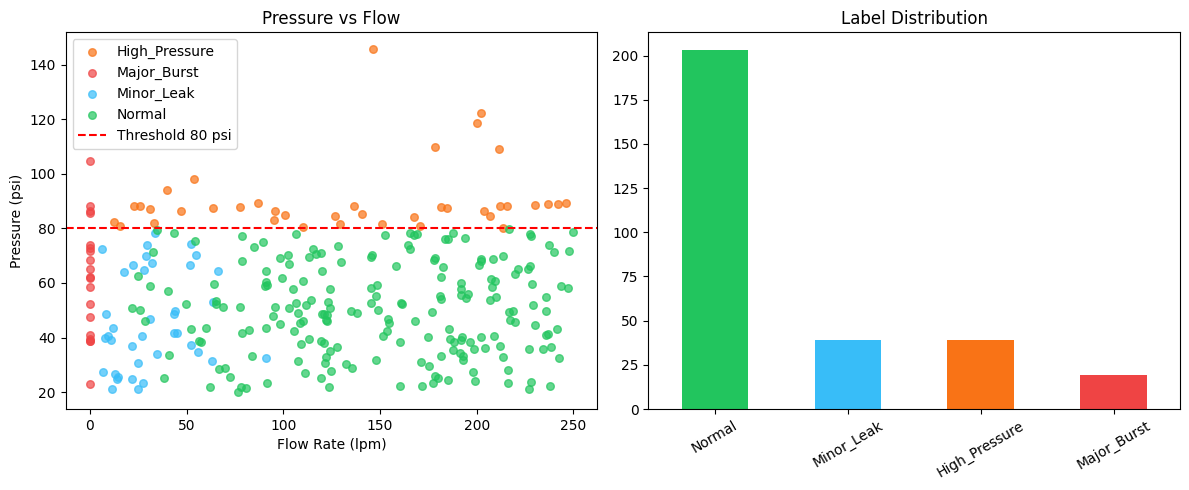

In [6]:
COLORS = {
    'Normal':        '#22c55e',
    'High_Pressure': '#f97316',
    'Minor_Leak':    '#38bdf8',
    'Major_Burst':   '#ef4444',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: Pressure vs Flow
ax = axes[0]
for label, grp in df.groupby('active_label'):
    ax.scatter(grp['flow_rate_lpm'], grp['pressure_psi'],
               label=label, alpha=0.7, s=30,
               color=COLORS.get(label, 'gray'))
ax.axhline(80, linestyle='--', color='red', label='Threshold 80 psi')
ax.set_title('Pressure vs Flow')
ax.set_xlabel('Flow Rate (lpm)')
ax.set_ylabel('Pressure (psi)')
ax.legend()

# Bar: Label counts
ax2 = axes[1]
counts = df['active_label'].value_counts()
counts.plot(kind='bar', ax=ax2,
            color=[COLORS.get(l, 'gray') for l in counts.index],
            edgecolor='none')
ax2.set_title('Label Distribution')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 💾 Save to CSV

In [7]:
path = save_csv(df)
info = saved_file_info()

print(f'✅ Saved to : {info["path"]}')
print(f'   Rows     : {info["rows"]}')
print(f'   Size     : {info["size_kb"]} KB')
print(f'   Time     : {info["modified"]}')
print()
print('▶ You can now run the app and choose "Load saved CSV" in the sidebar.')
print('  streamlit run app.py')

✅ Saved to : c:\Users\Shivam kumar\Desktop\Data Science Practice\SIC\Aquaguard\files\modules\..\data\sensor_data.csv
   Rows     : 300
   Size     : 24.2 KB
   Time     : 2026-03-18 11:46:34

▶ You can now run the app and choose "Load saved CSV" in the sidebar.
  streamlit run app.py
